# Credit Risk Assessment System

## Exploratory Data Analysis (EDA)

### Dataset
Home Credit Default Risk

### Objective
To understand the dataset by analyzing its structure, quality, missing values, distributions, relationships between variables, and key business insights before preprocessing and machine learning.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive')
os.makedirs('credit-risk-assessment-system/data/raw', exist_ok=True)
os.makedirs('credit-risk-assessment-system/data/processed', exist_ok=True)
os.chdir('credit-risk-assessment-system')

print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/credit-risk-assessment-system
['data']


In [3]:
!ls -la data/raw

total 1429962
-rw------- 1 root root 166133370 Dec 10  2019 application_train.csv
-rw------- 1 root root 170016717 Dec 10  2019 bureau.csv
-rw------- 1 root root     37383 Dec 10  2019 HomeCredit_columns_description.csv
-rw------- 1 root root 723118349 Dec 10  2019 installments_payments.csv
-rw------- 1 root root 404973293 Dec 10  2019 previous_application.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('data/raw/application_train.csv')

print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [9]:
df.describe(include="object").T

,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


⬜ Dataset Overview
⬜ Data Types
⬜ Missing Values
⬜ Duplicate Records
⬜ Target Variable Analysis
⬜ Numerical Feature Analysis
⬜ Categorical Feature Analysis
⬜ Outlier Detection
⬜ Correlation Analysis
⬜ Business Insights
⬜ EDA Conclusion

# 3. Data Quality Assessment

## 3.1 Missing Value Analysis

In [10]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
COMMONAREA_MEDI,214865
COMMONAREA_MODE,214865
COMMONAREA_AVG,214865
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_MEDI,213514
...,...
EXT_SOURCE_2,660
AMT_GOODS_PRICE,278
AMT_ANNUITY,12
CNT_FAM_MEMBERS,2


In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(ascending=False)

,0
COMMONAREA_MEDI,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_AVG,69.872297
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_MEDI,69.432963
...,...
EXT_SOURCE_2,0.214626
AMT_GOODS_PRICE,0.090403
AMT_ANNUITY,0.003902
CNT_FAM_MEMBERS,0.000650


In [12]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df))*100
})

missing_df = missing_df[missing_df["Missing Count"] > 0]

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
).head(20)

,Missing Count,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


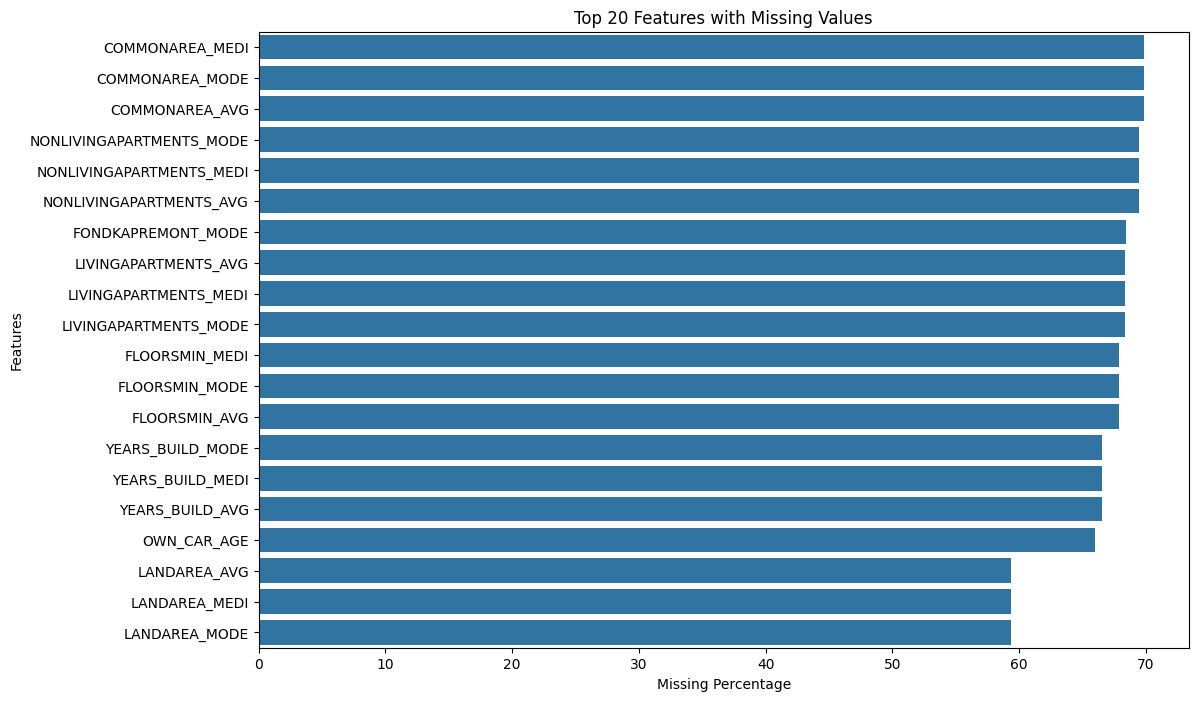

In [13]:
top_missing = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_missing["Missing Percentage"],
    y=top_missing.index
)

plt.title("Top 20 Features with Missing Values")

plt.xlabel("Missing Percentage")

plt.ylabel("Features")

plt.show()

### Observation

The missing value analysis reveals that several housing- and property-related features contain more than 60% missing values. Variables such as `COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `LIVINGAPARTMENTS_*`, `FLOORSMIN_*`, and `YEARS_BUILD_*` are missing for the majority of applicants.

This suggests that these attributes were either not collected for all customers or were only applicable to certain property types. Such a high percentage of missing values requires careful handling during preprocessing. Features with extremely high missingness may be removed, while others may require appropriate imputation techniques depending on their importance.

Duplicate Analysis

In [14]:
df.duplicated().sum()

np.int64(0)

Target Variable


In [15]:
df["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


In [16]:
df["TARGET"].value_counts(normalize=True) * 100

,proportion
TARGET,
0,91.927118
1,8.072882


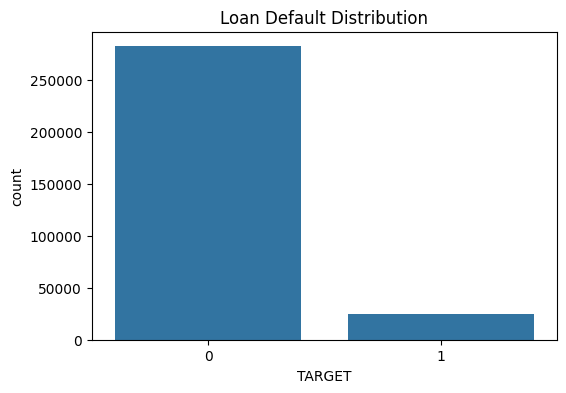

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="TARGET", data=df)

plt.title("Loan Default Distribution")

plt.show()

### Observation

The target variable represents whether a customer defaulted on the loan.

- TARGET = 0 indicates that the client successfully repaid the loan.
- TARGET = 1 indicates that the client experienced payment difficulties or defaulted.

The class distribution is highly imbalanced, with approximately 92% of applicants belonging to the non-default class and only about 8% belonging to the default class.

This imbalance is expected in real-world credit risk datasets because the majority of customers repay their loans.

The imbalance should be considered during model development. Accuracy alone will not be an appropriate evaluation metric. Instead, metrics such as ROC-AUC, Precision, Recall, F1-score, and techniques such as class weighting or SMOTE may be considered.

Numerical Feature Analysis

In [18]:
important_num = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

df[important_num].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


In [ ]:
df["AGE"] = abs(df["DAYS_BIRTH"]) / 365

In [20]:
df["AGE"].describe()

,AGE
count,307511.000000
mean,43.936973
std,11.956133
min,20.517808
25%,34.008219
50%,43.150685
75%,53.923288
max,69.120548


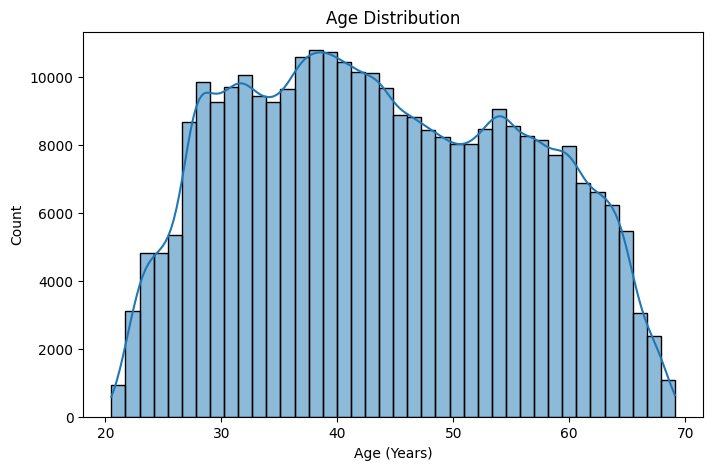

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["AGE"], bins=40, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age (Years)")

plt.show()

### Observation

The age distribution indicates that most loan applicants are between 30 and 60 years of age, representing the economically active population.

Very few applicants are younger than 25 years or older than 65 years, which is expected because financial institutions generally prefer lending to applicants with stable employment and predictable income.

No abnormal or unrealistic age values were observed, indicating good data quality for the AGE feature.

In [22]:
df["AMT_INCOME_TOTAL"].describe()

,AMT_INCOME_TOTAL
count,3.075110e+05
mean,1.687979e+05
std,2.371231e+05
min,2.565000e+04
25%,1.125000e+05
50%,1.471500e+05
75%,2.025000e+05
max,1.170000e+08


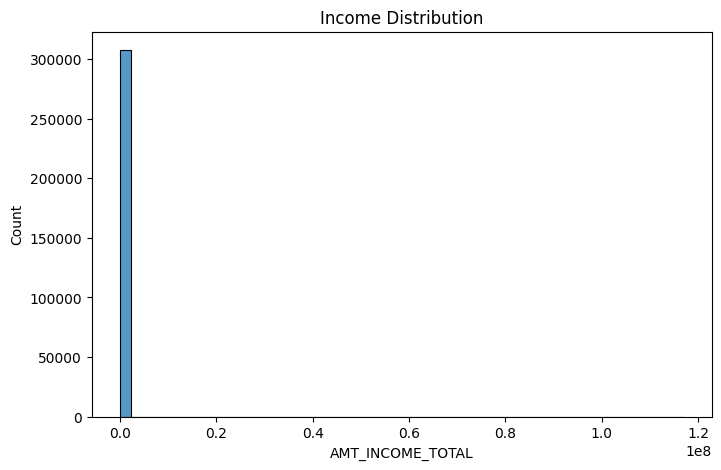

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["AMT_INCOME_TOTAL"], bins=50)

plt.title("Income Distribution")

plt.show()

In [24]:
df["AMT_INCOME_TOTAL"].describe()

,AMT_INCOME_TOTAL
count,3.075110e+05
mean,1.687979e+05
std,2.371231e+05
min,2.565000e+04
25%,1.125000e+05
50%,1.471500e+05
75%,2.025000e+05
max,1.170000e+08


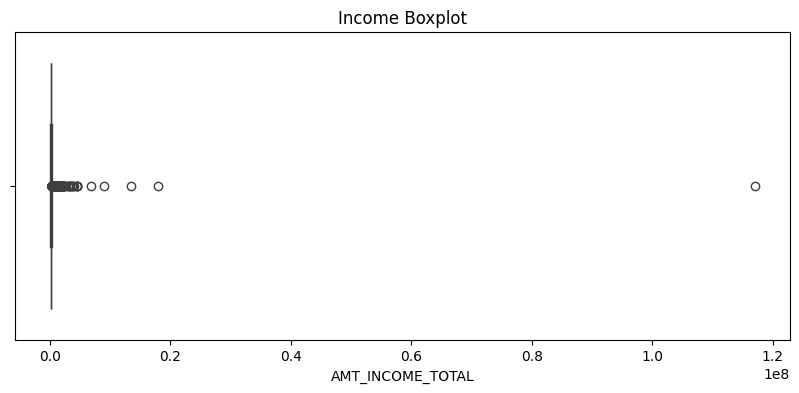

In [25]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["AMT_INCOME_TOTAL"])

plt.title("Income Boxplot")
plt.show()

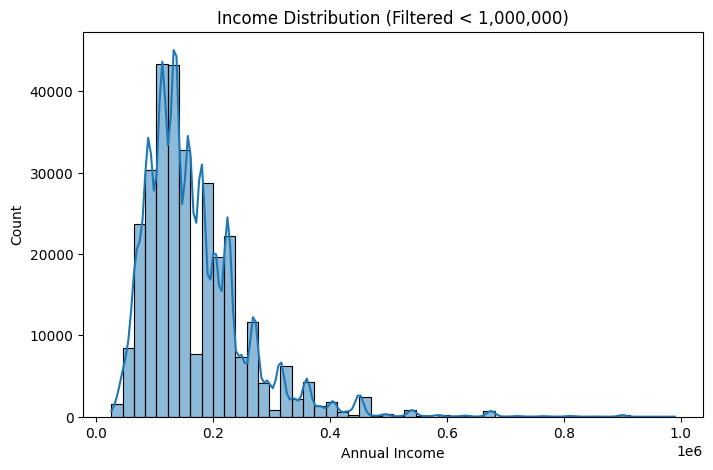

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    df[df["AMT_INCOME_TOTAL"] < 1000000]["AMT_INCOME_TOTAL"],
    bins=50,
    kde=True
)

plt.title("Income Distribution (Filtered < 1,000,000)")

plt.xlabel("Annual Income")

plt.show()

### Observation

The annual income distribution is highly right-skewed. Most applicants have relatively low to moderate annual incomes, while a small number of applicants report extremely high incomes. These extreme values compress the histogram, making it difficult to visualize the distribution of the majority of applicants.

Further investigation using summary statistics and boxplots is required to determine whether these values are valid high-income applicants or potential outliers.

Credit Amount Analysis

In [27]:
print(df["AMT_CREDIT"].describe())

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64


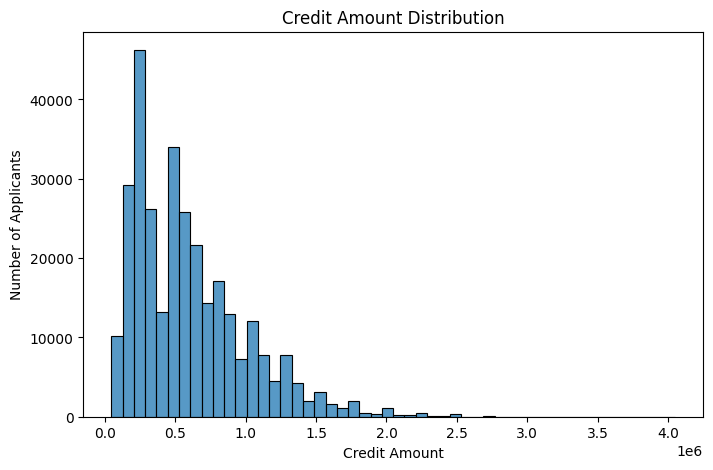

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["AMT_CREDIT"], bins=50)

plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Number of Applicants")

plt.show()

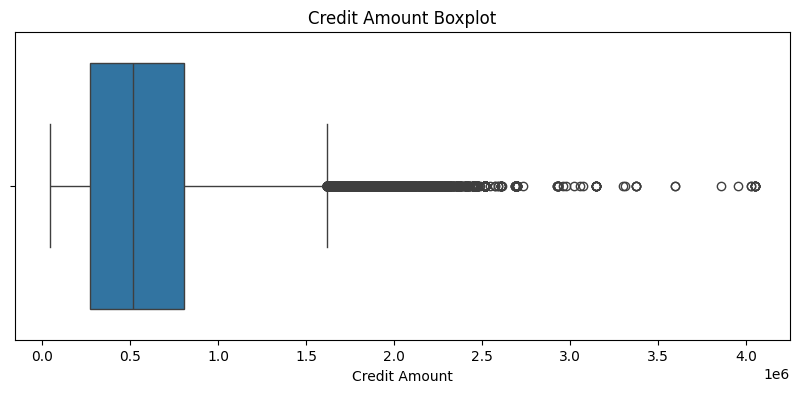

In [29]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["AMT_CREDIT"])

plt.title("Credit Amount Boxplot")
plt.xlabel("Credit Amount")

plt.show()

Annuity Analysis

In [30]:
print(df["AMT_ANNUITY"].describe())

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64


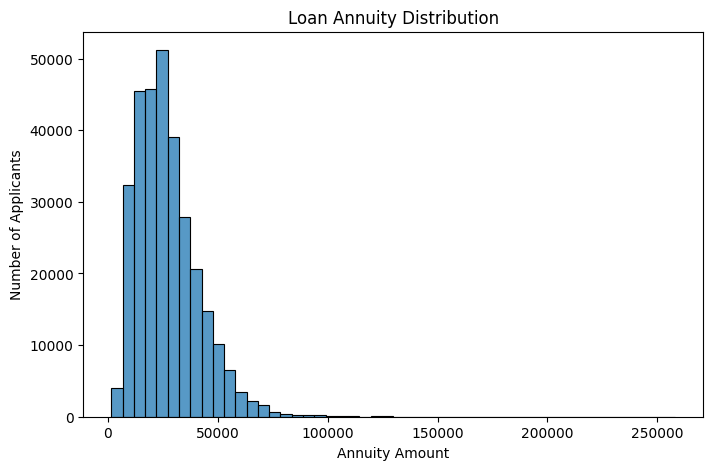

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["AMT_ANNUITY"], bins=50)

plt.title("Loan Annuity Distribution")
plt.xlabel("Annuity Amount")
plt.ylabel("Number of Applicants")

plt.show()

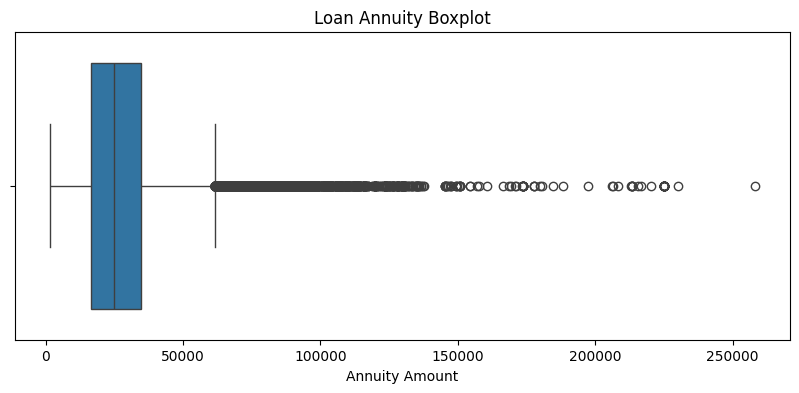

In [32]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["AMT_ANNUITY"])

plt.title("Loan Annuity Boxplot")
plt.xlabel("Annuity Amount")

plt.show()

Goods Price

In [33]:
print(df["AMT_GOODS_PRICE"].describe())

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64


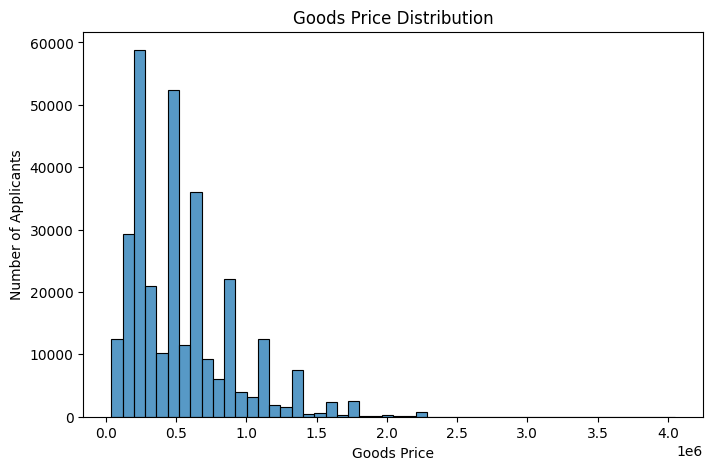

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df["AMT_GOODS_PRICE"], bins=50)

plt.title("Goods Price Distribution")
plt.xlabel("Goods Price")
plt.ylabel("Number of Applicants")

plt.show()

Employment Duration

In [35]:
df["EMPLOYED_YEARS"] = abs(df["DAYS_EMPLOYED"]) / 365

In [36]:
print(df["EMPLOYED_YEARS"].describe())

count    307511.000000
mean        185.547239
std         382.037676
min           0.000000
25%           2.556164
50%           6.079452
75%          15.635616
max        1000.665753
Name: EMPLOYED_YEARS, dtype: float64


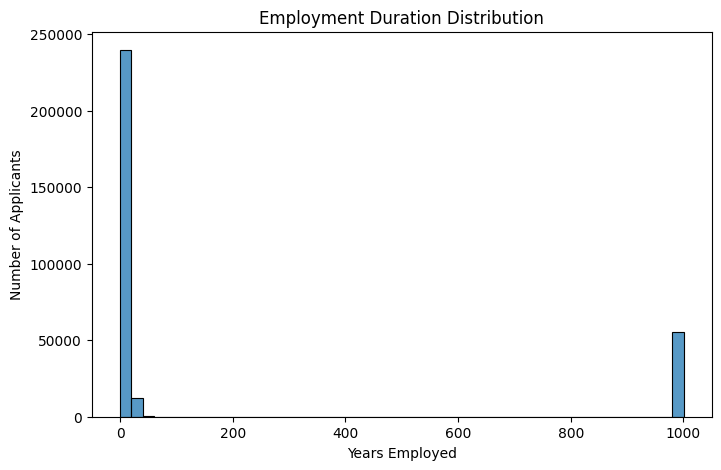

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["EMPLOYED_YEARS"], bins=50)

plt.title("Employment Duration Distribution")
plt.xlabel("Years Employed")
plt.ylabel("Number of Applicants")

plt.show()

Number of Children

In [38]:
print(df["CNT_CHILDREN"].describe())

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64


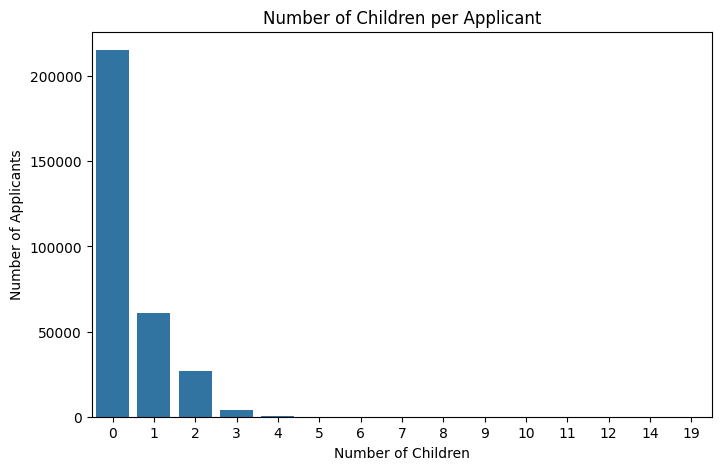

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["CNT_CHILDREN"]
)

plt.title("Number of Children per Applicant")
plt.xlabel("Number of Children")
plt.ylabel("Number of Applicants")

plt.show()

Family Members

In [40]:
print(df["CNT_FAM_MEMBERS"].describe())

count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64


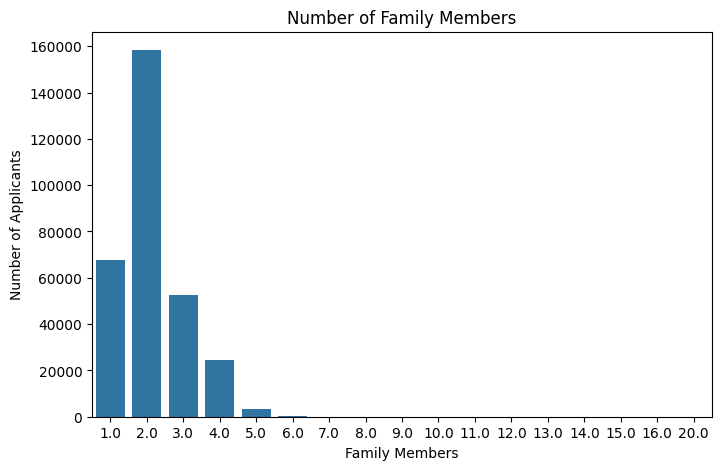

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["CNT_FAM_MEMBERS"]
)

plt.title("Number of Family Members")
plt.xlabel("Family Members")
plt.ylabel("Number of Applicants")

plt.show()

Bivariate analysis

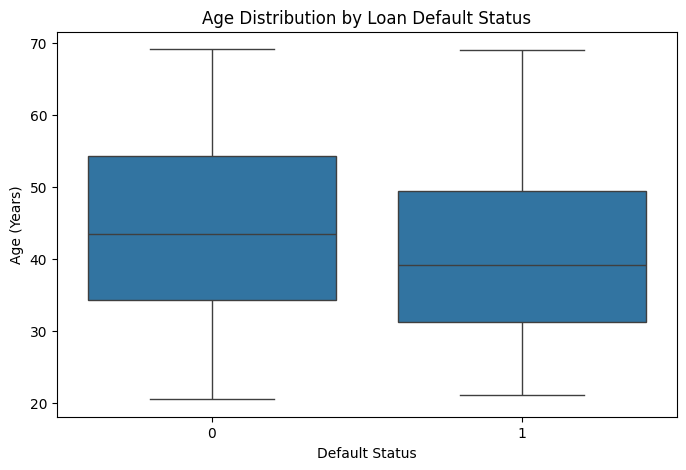

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="TARGET",
    y="AGE",
    data=df
)

plt.title("Age Distribution by Loan Default Status")
plt.xlabel("Default Status")
plt.ylabel("Age (Years)")

plt.show()

Age vs Default

In [43]:
df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70],
    right=False
)

In [44]:
age_default_rate = (
    df.groupby("AGE_GROUP", observed=True)["TARGET"]
      .mean()
      .mul(100)
)

print(age_default_rate)

AGE_GROUP
[20, 25)    12.312757
[25, 30)    11.138508
[30, 35)    10.286772
[35, 40)     8.931405
[40, 45)     7.859281
[45, 50)     7.415948
[50, 55)     6.699674
[55, 60)     5.529398
[60, 65)     5.277909
[65, 70)     3.718296
Name: TARGET, dtype: float64


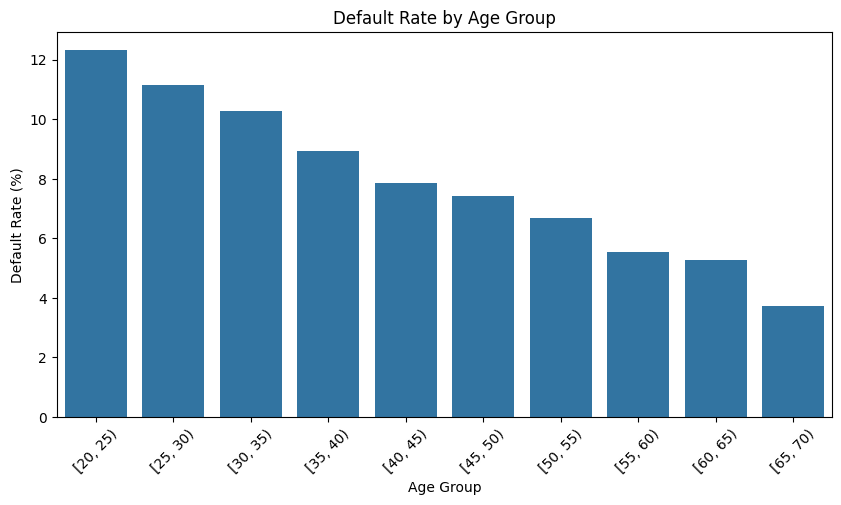

In [45]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=age_default_rate.index.astype(str),
    y=age_default_rate.values
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.show()

Income vs Default

In [46]:
df["INCOME_GROUP"] = pd.qcut(
    df["AMT_INCOME_TOTAL"],
    q=5,
    duplicates="drop"
)

In [47]:
income_default_rate = (
    df.groupby("INCOME_GROUP", observed=True)["TARGET"]
      .mean()
      .mul(100)
)

print(income_default_rate)

INCOME_GROUP
(25649.999, 99000.0]       8.206248
(99000.0, 135000.0]        8.588320
(135000.0, 162000.0]       8.684738
(162000.0, 225000.0]       8.056891
(225000.0, 117000000.0]    6.519801
Name: TARGET, dtype: float64


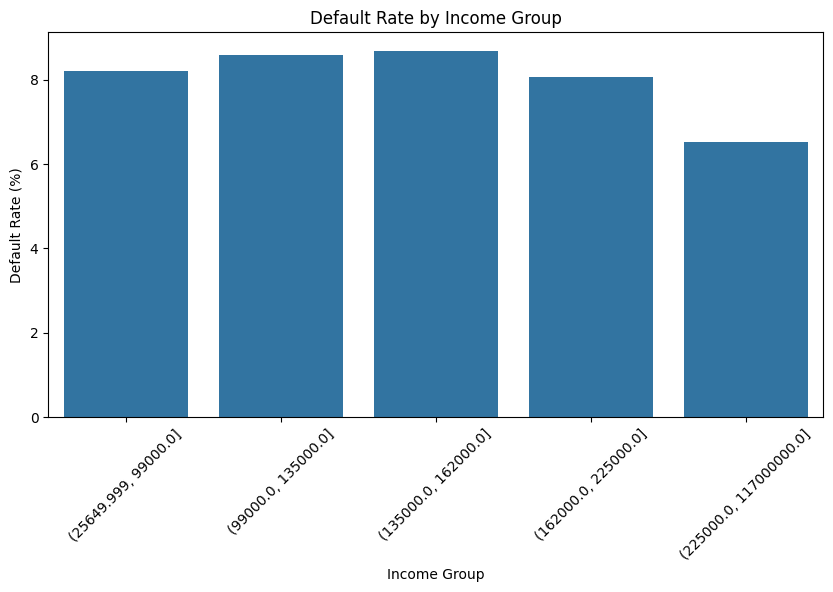

In [48]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=income_default_rate.index.astype(str),
    y=income_default_rate.values
)

plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.show()

Categorical Analysis

In [49]:
print(df["NAME_CONTRACT_TYPE"].value_counts())

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64


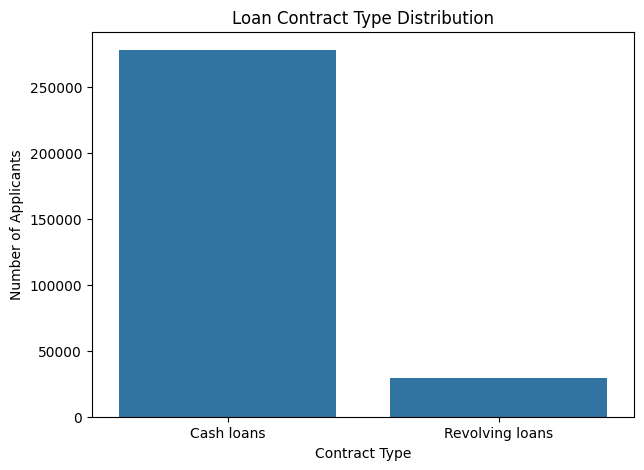

In [50]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="NAME_CONTRACT_TYPE",
    data=df
)

plt.title("Loan Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Applicants")

plt.show()

In [51]:
contract_default_rate = (
    df.groupby("NAME_CONTRACT_TYPE")["TARGET"]
      .mean()
      .mul(100)
)

print(contract_default_rate)

NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64


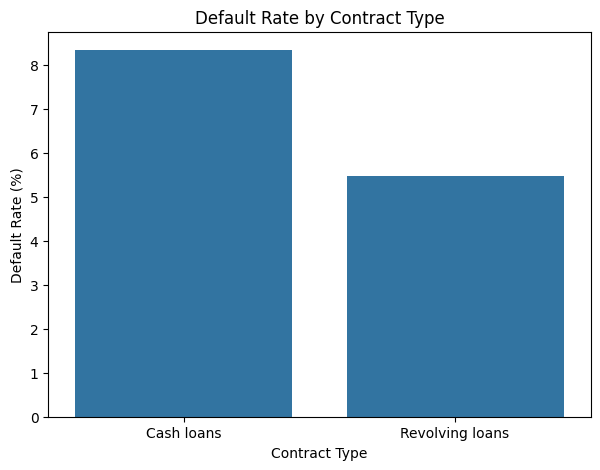

In [52]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=contract_default_rate.index,
    y=contract_default_rate.values
)

plt.title("Default Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Default Rate (%)")

plt.show()

Gender

In [53]:
print(df["CODE_GENDER"].value_counts())

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


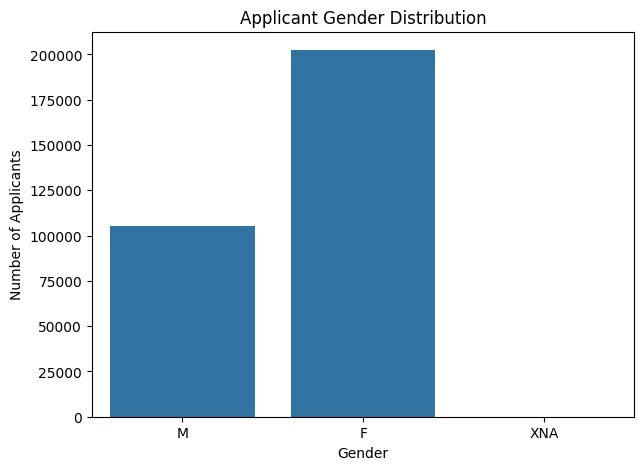

In [54]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="CODE_GENDER",
    data=df
)

plt.title("Applicant Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")

plt.show()

In [55]:
gender_default_rate = (
    df.groupby("CODE_GENDER")["TARGET"]
      .mean()
      .mul(100)
)

print(gender_default_rate)

CODE_GENDER
F       6.999328
M      10.141920
XNA     0.000000
Name: TARGET, dtype: float64


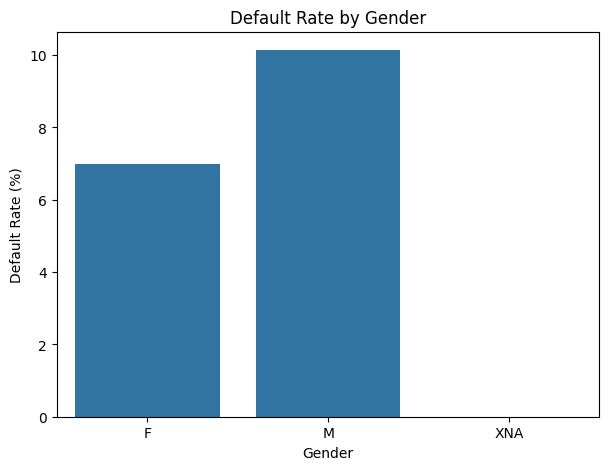

In [56]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=gender_default_rate.index,
    y=gender_default_rate.values
)

plt.title("Default Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Default Rate (%)")

plt.show()

Education

In [57]:
print(df["NAME_EDUCATION_TYPE"].value_counts())

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64


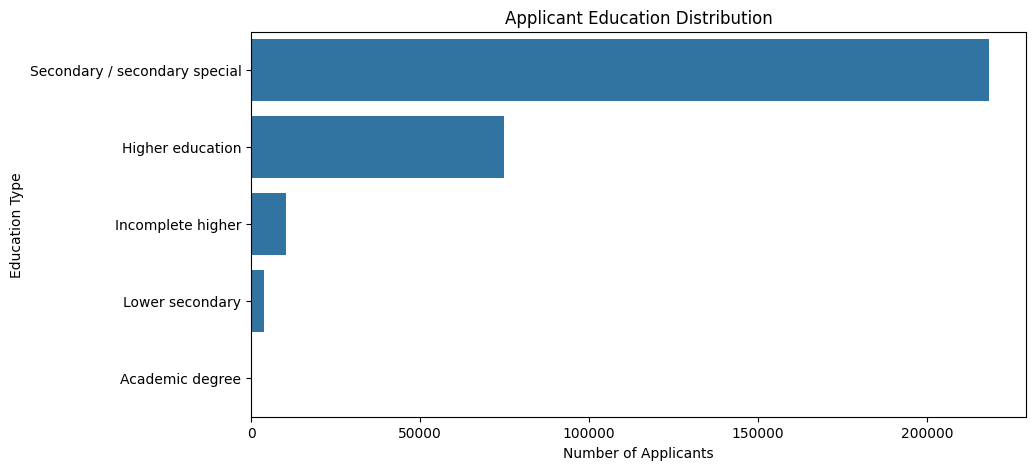

In [58]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="NAME_EDUCATION_TYPE",
    data=df,
    order=df["NAME_EDUCATION_TYPE"].value_counts().index
)

plt.title("Applicant Education Distribution")
plt.xlabel("Number of Applicants")
plt.ylabel("Education Type")

plt.show()

In [59]:
education_default_rate = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(education_default_rate)

NAME_EDUCATION_TYPE
Lower secondary                  10.927673
Secondary / secondary special     8.939929
Incomplete higher                 8.484966
Higher education                  5.355115
Academic degree                   1.829268
Name: TARGET, dtype: float64


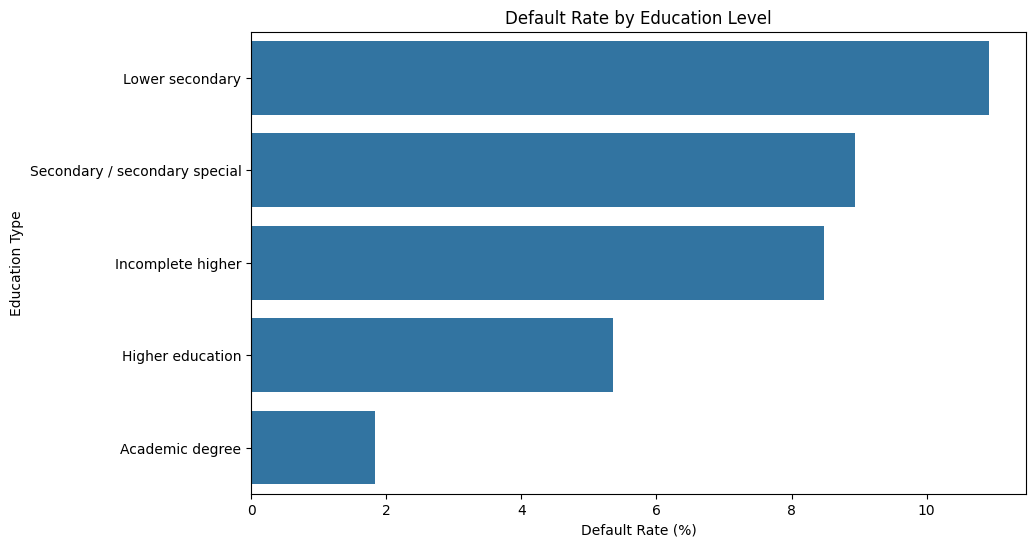

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=education_default_rate.values,
    y=education_default_rate.index
)

plt.title("Default Rate by Education Level")
plt.xlabel("Default Rate (%)")
plt.ylabel("Education Type")

plt.show()

Income Type

In [61]:
print(df["NAME_INCOME_TYPE"].value_counts())

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64


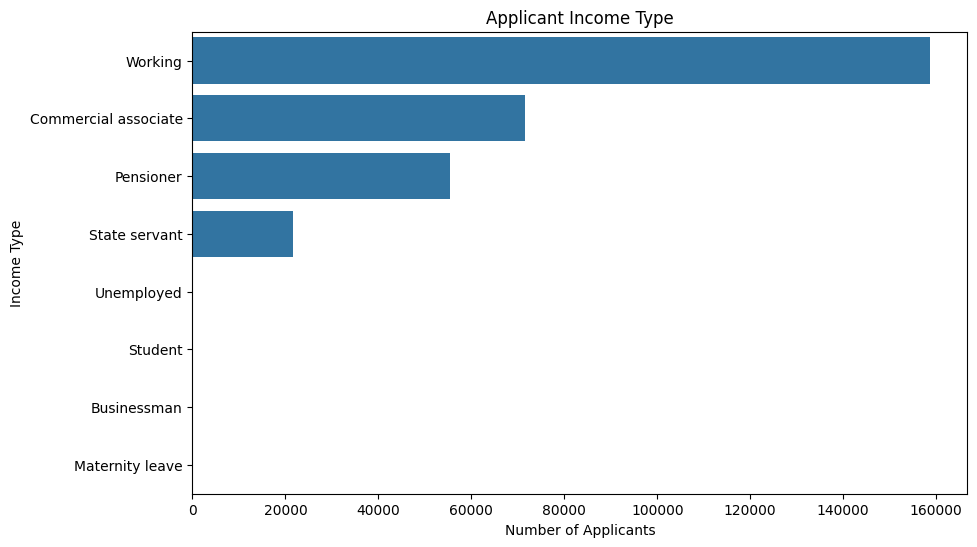

In [62]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="NAME_INCOME_TYPE",
    data=df,
    order=df["NAME_INCOME_TYPE"].value_counts().index
)

plt.title("Applicant Income Type")
plt.xlabel("Number of Applicants")
plt.ylabel("Income Type")

plt.show()

In [63]:
income_type_default_rate = (
    df.groupby("NAME_INCOME_TYPE")["TARGET"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(income_type_default_rate)

NAME_INCOME_TYPE
Maternity leave         40.000000
Unemployed              36.363636
Working                  9.588472
Commercial associate     7.484257
State servant            5.754965
Pensioner                5.386366
Businessman              0.000000
Student                  0.000000
Name: TARGET, dtype: float64


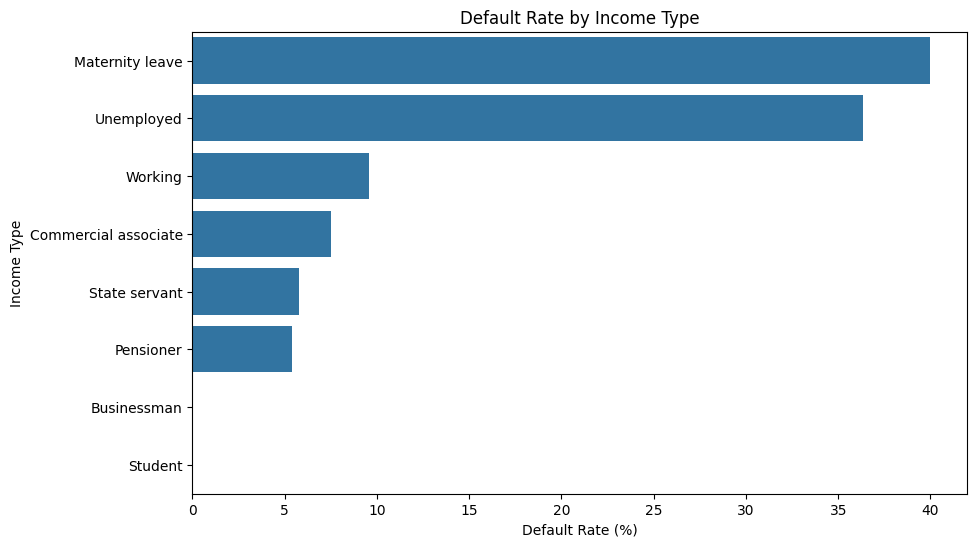

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=income_type_default_rate.values,
    y=income_type_default_rate.index
)

plt.title("Default Rate by Income Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Income Type")

plt.show()

Family Status

In [65]:
print(df["NAME_FAMILY_STATUS"].value_counts())

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64


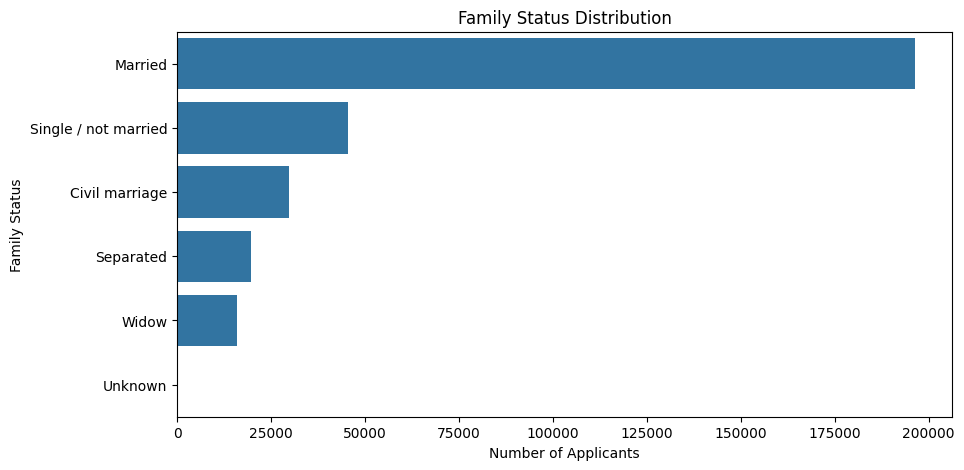

In [66]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="NAME_FAMILY_STATUS",
    data=df,
    order=df["NAME_FAMILY_STATUS"].value_counts().index
)

plt.title("Family Status Distribution")
plt.xlabel("Number of Applicants")
plt.ylabel("Family Status")

plt.show()

In [67]:
family_default_rate = (
    df.groupby("NAME_FAMILY_STATUS")["TARGET"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(family_default_rate)

NAME_FAMILY_STATUS
Civil marriage          9.944584
Single / not married    9.807675
Separated               8.194234
Married                 7.559868
Widow                   5.824217
Unknown                 0.000000
Name: TARGET, dtype: float64


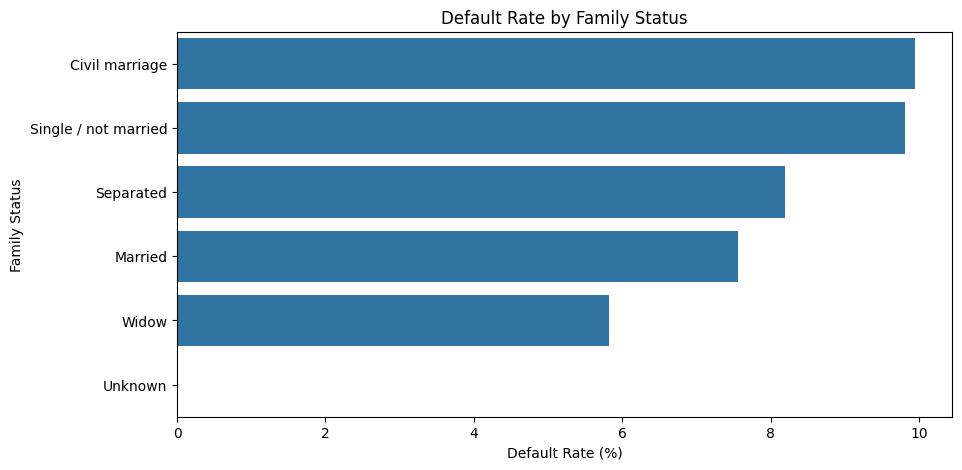

In [68]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=family_default_rate.values,
    y=family_default_rate.index
)

plt.title("Default Rate by Family Status")
plt.xlabel("Default Rate (%)")
plt.ylabel("Family Status")

plt.show()

Housing Type

In [69]:
print(df["NAME_HOUSING_TYPE"].value_counts())

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64


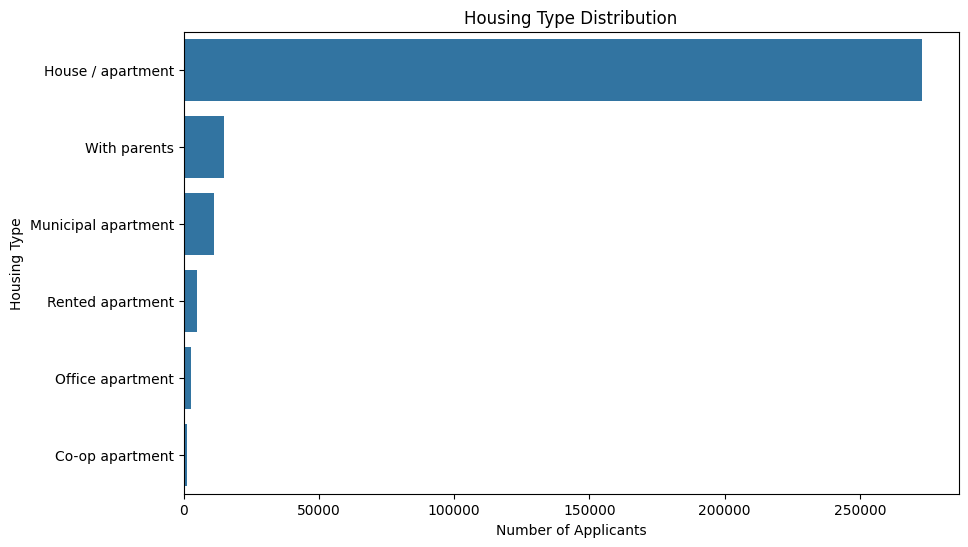

In [70]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="NAME_HOUSING_TYPE",
    data=df,
    order=df["NAME_HOUSING_TYPE"].value_counts().index
)

plt.title("Housing Type Distribution")
plt.xlabel("Number of Applicants")
plt.ylabel("Housing Type")

plt.show()

In [71]:
housing_default_rate = (
    df.groupby("NAME_HOUSING_TYPE")["TARGET"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(housing_default_rate)

NAME_HOUSING_TYPE
Rented apartment       12.313051
With parents           11.698113
Municipal apartment     8.539748
Co-op apartment         7.932264
House / apartment       7.795711
Office apartment        6.572411
Name: TARGET, dtype: float64


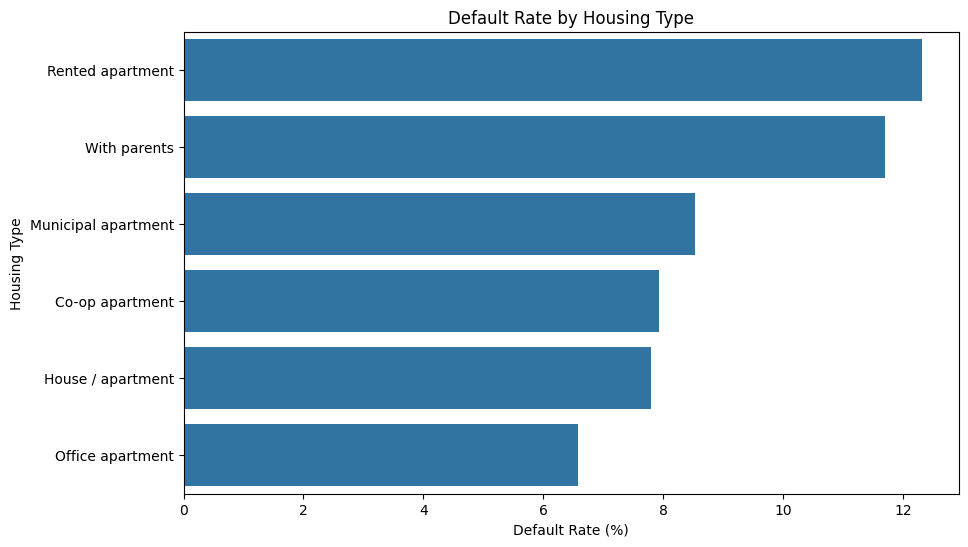

In [72]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=housing_default_rate.values,
    y=housing_default_rate.index
)

plt.title("Default Rate by Housing Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Housing Type")

plt.show()

Occupation

In [73]:
print(df["OCCUPATION_TYPE"].value_counts(dropna=False))

OCCUPATION_TYPE
NaN                      96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64


In [74]:
occupation_default_rate = (
    df.groupby("OCCUPATION_TYPE", dropna=False)["TARGET"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(occupation_default_rate)

OCCUPATION_TYPE
Low-skill Laborers       17.152413
Drivers                  11.326130
Waiters/barmen staff     11.275964
Security staff           10.742449
Laborers                 10.578770
Cooking staff            10.443996
Sales staff               9.631799
Cleaning staff            9.606705
Realty agents             7.856192
Secretaries               7.049808
Medicine staff            6.700246
Private service staff     6.598793
NaN                       6.513056
IT staff                  6.463878
HR staff                  6.394316
Core staff                6.303954
Managers                  6.214028
High skill tech staff     6.159930
Accountants               4.830327
Name: TARGET, dtype: float64


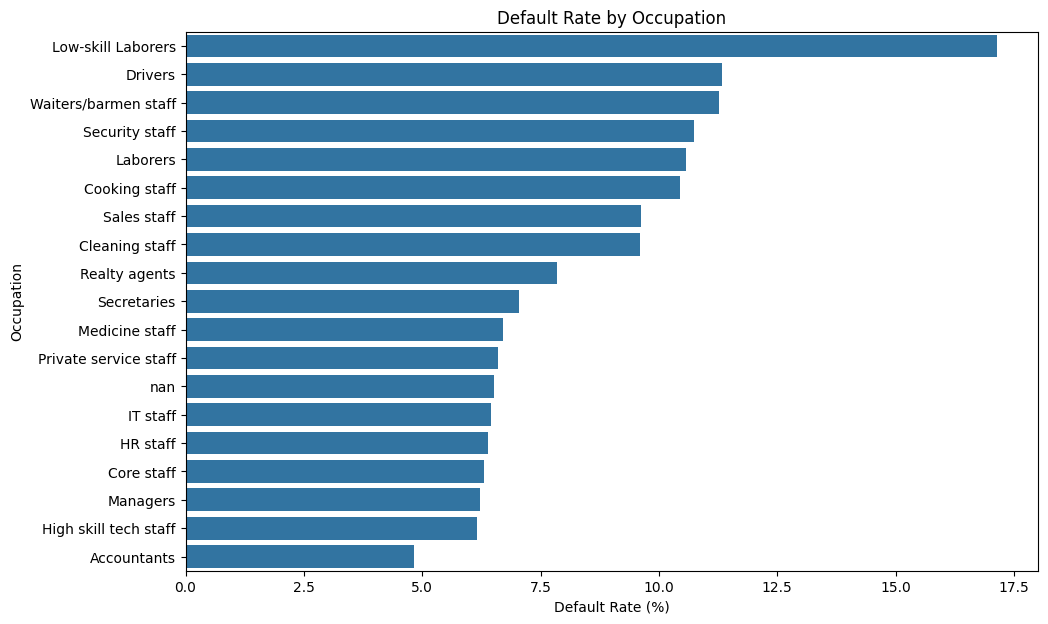

In [75]:
plt.figure(figsize=(11,7))

sns.barplot(
    x=occupation_default_rate.values,
    y=occupation_default_rate.index.astype(str)
)

plt.title("Default Rate by Occupation")
plt.xlabel("Default Rate (%)")
plt.ylabel("Occupation")

plt.show()

Correlation Analysis

In [76]:
target_corr = df.corr(numeric_only=True)["TARGET"].sort_values()

print("Most negatively correlated features:")
print(target_corr.head(15))

print("\nMost positively correlated features:")
print(target_corr.tail(15))

Most negatively correlated features:
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
AGE                          -0.078239
EMPLOYED_YEARS               -0.047046
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
ELEVATORS_MEDI               -0.033863
FLOORSMIN_AVG                -0.033614
FLOORSMIN_MEDI               -0.033394
Name: TARGET, dtype: float64

Most positively correlated features:
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 

correlations with TARGET


In [77]:
target_corr = df.corr(numeric_only=True)["TARGET"].sort_values()

print("Most negatively correlated features:")
print(target_corr.head(15))

print("\nMost positively correlated features:")
print(target_corr.tail(15))

Most negatively correlated features:
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
AGE                          -0.078239
EMPLOYED_YEARS               -0.047046
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
ELEVATORS_MEDI               -0.033863
FLOORSMIN_AVG                -0.033614
FLOORSMIN_MEDI               -0.033394
Name: TARGET, dtype: float64

Most positively correlated features:
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 

In [78]:
top_corr_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

print(top_corr_features)

Index(['TARGET', 'EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'AGE',
       'DAYS_BIRTH', 'REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT',
       'DAYS_LAST_PHONE_CHANGE', 'DAYS_ID_PUBLISH', 'REG_CITY_NOT_WORK_CITY',
       'EMPLOYED_YEARS', 'FLAG_EMP_PHONE', 'DAYS_EMPLOYED',
       'REG_CITY_NOT_LIVE_CITY'],
      dtype='object')


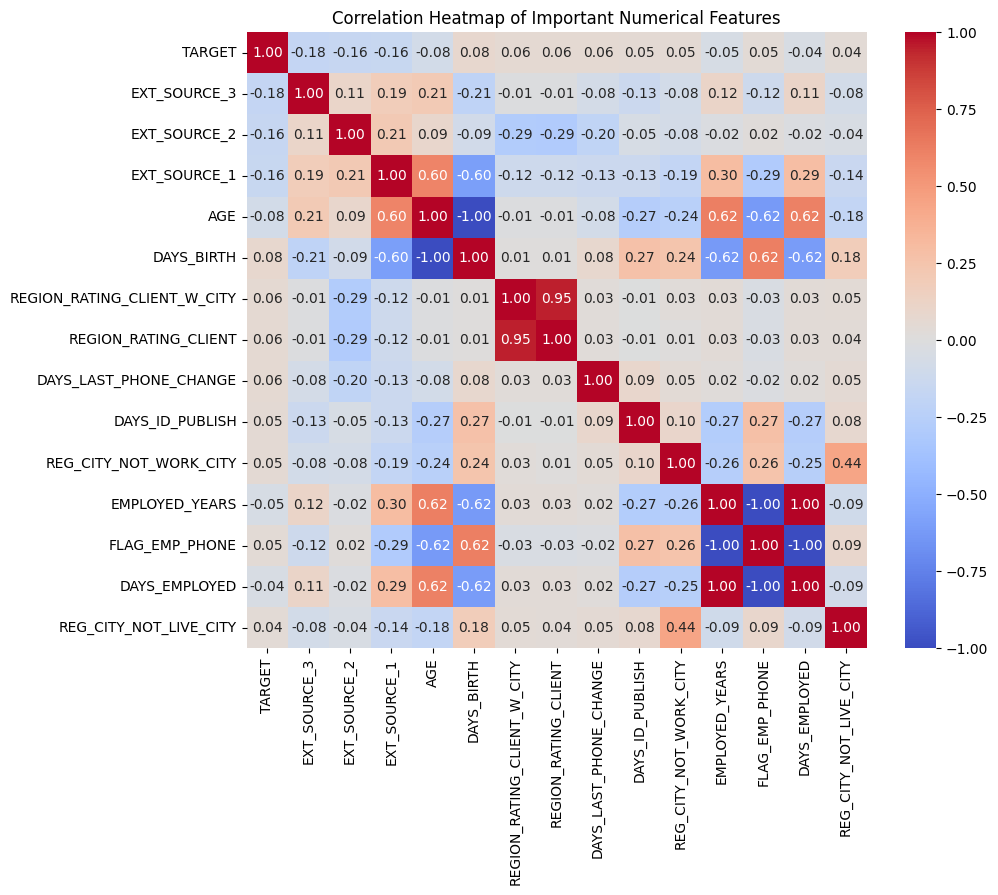

In [79]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_corr_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Important Numerical Features")

plt.show()

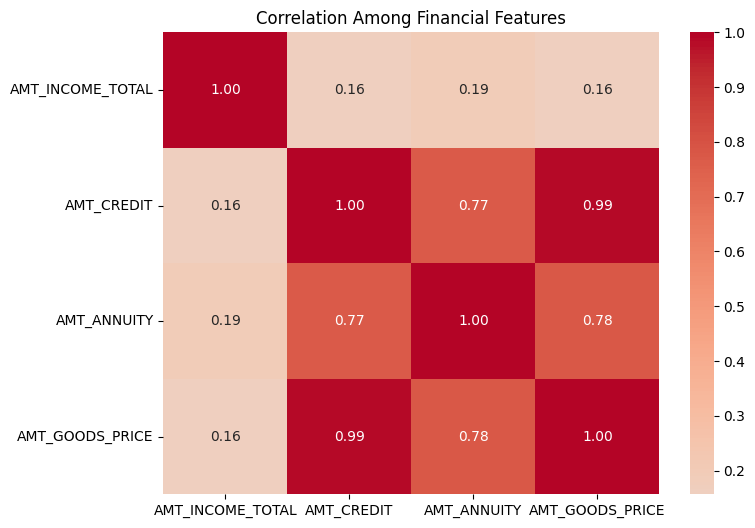

In [80]:
financial_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[financial_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Among Financial Features")

plt.show()

Default Rate by Loan Amount

In [81]:
df["CREDIT_GROUP"] = pd.qcut(
    df["AMT_CREDIT"],
    q=5,
    duplicates="drop"
)

In [82]:
credit_default_rate = (
    df.groupby("CREDIT_GROUP", observed=True)["TARGET"]
      .mean()
      .mul(100)
)

print(credit_default_rate)

CREDIT_GROUP
(44999.999, 254700.0]     7.237582
(254700.0, 432000.0]      9.172433
(432000.0, 604152.0]     10.054913
(604152.0, 900000.0]      7.854867
(900000.0, 4050000.0]     6.075163
Name: TARGET, dtype: float64


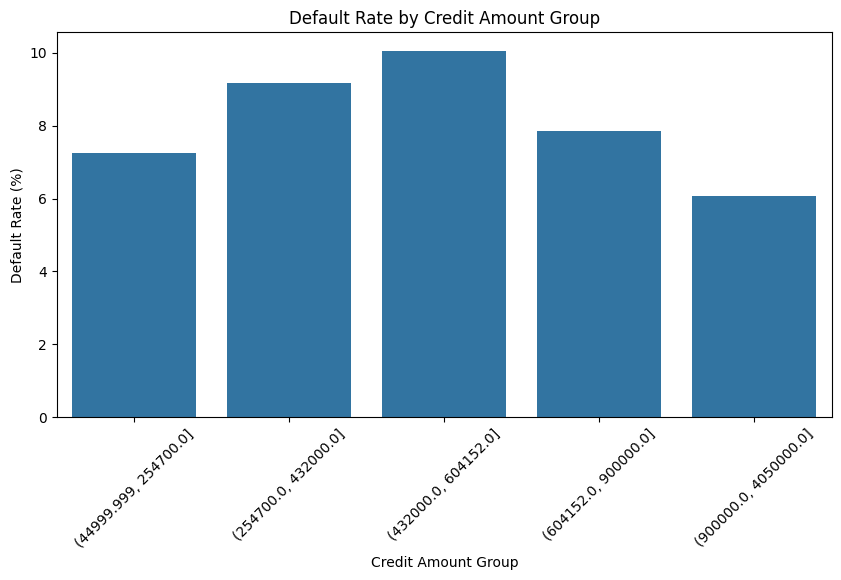

In [83]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=credit_default_rate.index.astype(str),
    y=credit_default_rate.values
)

plt.title("Default Rate by Credit Amount Group")
plt.xlabel("Credit Amount Group")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.show()

Credit-to-Income Ratio

In [84]:
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

In [85]:
print(df["CREDIT_INCOME_RATIO"].describe())

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_INCOME_RATIO, dtype: float64


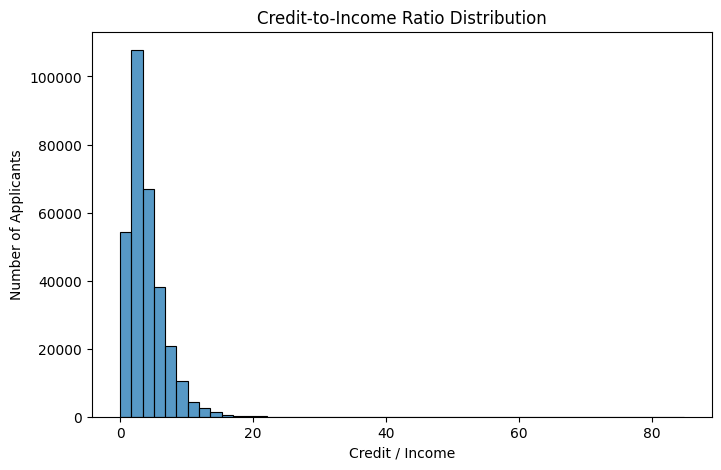

In [86]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["CREDIT_INCOME_RATIO"],
    bins=50
)

plt.title("Credit-to-Income Ratio Distribution")
plt.xlabel("Credit / Income")
plt.ylabel("Number of Applicants")

plt.show()

In [87]:
df["CREDIT_INCOME_GROUP"] = pd.qcut(
    df["CREDIT_INCOME_RATIO"],
    q=5,
    duplicates="drop"
)

ratio_default_rate = (
    df.groupby("CREDIT_INCOME_GROUP", observed=True)["TARGET"]
      .mean()
      .mul(100)
)

print(ratio_default_rate)

CREDIT_INCOME_GROUP
(0.00381, 1.818]    7.335186
(1.818, 2.764]      8.567201
(2.764, 3.906]      8.925259
(3.906, 5.769]      8.283879
(5.769, 84.737]     7.253776
Name: TARGET, dtype: float64


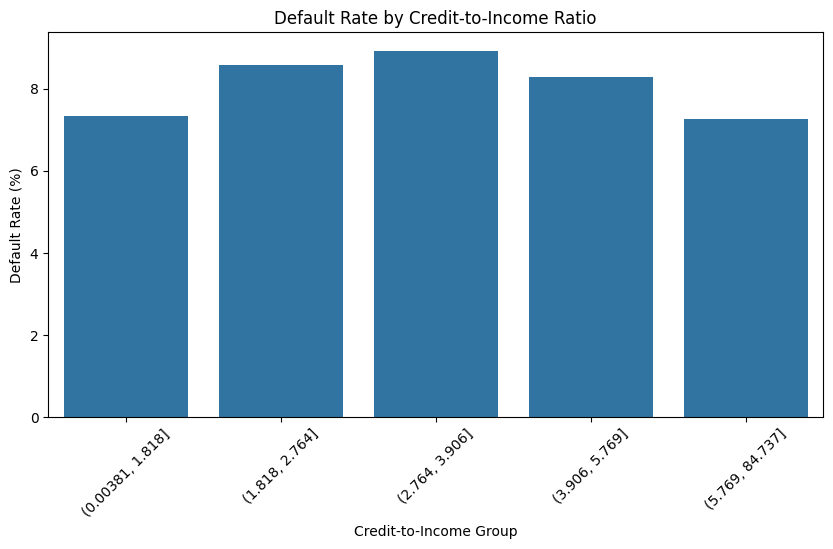

In [88]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=ratio_default_rate.index.astype(str),
    y=ratio_default_rate.values
)

plt.title("Default Rate by Credit-to-Income Ratio")
plt.xlabel("Credit-to-Income Group")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.show()

annuity relative to income.

In [89]:
df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

In [90]:
print(df["ANNUITY_INCOME_RATIO"].describe())

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: ANNUITY_INCOME_RATIO, dtype: float64


In [91]:
df["ANNUITY_INCOME_GROUP"] = pd.qcut(
    df["ANNUITY_INCOME_RATIO"],
    q=5,
    duplicates="drop"
)

In [92]:
annuity_default_rate = (
    df.groupby("ANNUITY_INCOME_GROUP", observed=True)["TARGET"]
      .mean()
      .mul(100)
)

print(annuity_default_rate)

ANNUITY_INCOME_GROUP
(-0.000776, 0.104]    7.196748
(0.104, 0.144]        7.831629
(0.144, 0.186]        8.125996
(0.186, 0.247]        8.696076
(0.247, 1.876]        8.515518
Name: TARGET, dtype: float64


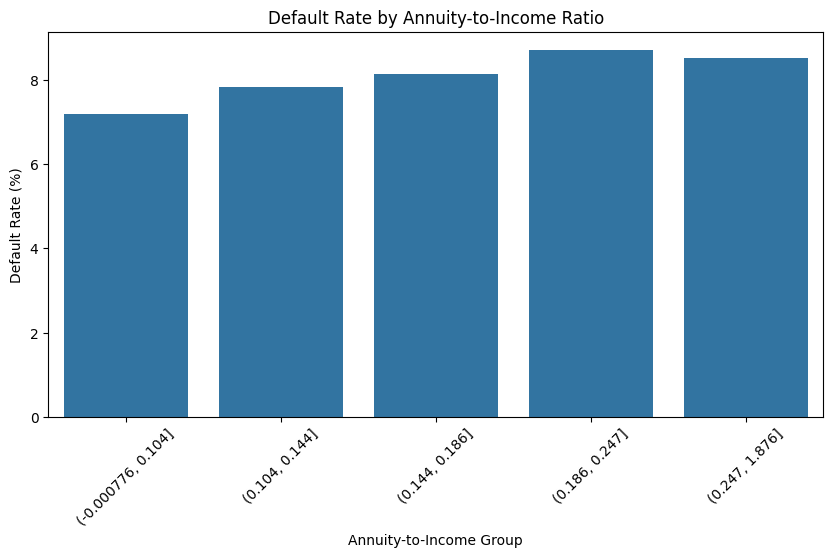

In [93]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=annuity_default_rate.index.astype(str),
    y=annuity_default_rate.values
)

plt.title("Default Rate by Annuity-to-Income Ratio")
plt.xlabel("Annuity-to-Income Group")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.show()

Outlier Analysis

In [94]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(len(numeric_cols))

110


In [95]:
outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outlier_Count": outliers,
        "Outlier_Percentage": round(
            outliers / len(df) * 100, 2
        )
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    "Outlier_Percentage",
    ascending=False
)

outlier_df.head(20)

,Feature,Outlier_Count,Outlier_Percentage
20,REGION_RATING_CLIENT,80527,26.19
21,REGION_RATING_CLIENT_W_CITY,78027,25.37
9,DAYS_EMPLOYED,72217,23.48
27,REG_CITY_NOT_WORK_CITY,70867,23.05
15,FLAG_WORK_PHONE,61308,19.94
107,EMPLOYED_YEARS,56357,18.33
14,FLAG_EMP_PHONE,55386,18.01
28,LIVE_CITY_NOT_WORK_CITY,55215,17.96
104,AMT_REQ_CREDIT_BUREAU_QRT,50575,16.45
103,AMT_REQ_CREDIT_BUREAU_MON,43759,14.23


DAYS_EMPLOYED Anomaly

In [96]:
print(df["DAYS_EMPLOYED"].describe())

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


In [97]:
print(
    df["DAYS_EMPLOYED"].value_counts().head(10)
)

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
-212         150
-384         143
-229         143
-231         140
-207         138
Name: count, dtype: int64


In [98]:
print(
    df[df["DAYS_EMPLOYED"] > 0]["DAYS_EMPLOYED"].value_counts()
)

DAYS_EMPLOYED
365243    55374
Name: count, dtype: int64


Default Rate by Employment Anomaly

In [99]:
anomaly_count = (df["DAYS_EMPLOYED"] == 365243).sum()

print("Anomalous records:", anomaly_count)

print(
    "Percentage:",
    round(anomaly_count / len(df) * 100, 2),
    "%"
)

Anomalous records: 55374
Percentage: 18.01 %


In [100]:
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

In [101]:
df["EMPLOYED_YEARS"] = abs(df["DAYS_EMPLOYED_CLEAN"]) / 365

In [102]:
print(df["EMPLOYED_YEARS"].describe())

count    252137.000000
mean          6.531971
std           6.406466
min           0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: EMPLOYED_YEARS, dtype: float64


In [103]:
outlier_df.head(20)

,Feature,Outlier_Count,Outlier_Percentage
20,REGION_RATING_CLIENT,80527,26.19
21,REGION_RATING_CLIENT_W_CITY,78027,25.37
9,DAYS_EMPLOYED,72217,23.48
27,REG_CITY_NOT_WORK_CITY,70867,23.05
15,FLAG_WORK_PHONE,61308,19.94
107,EMPLOYED_YEARS,56357,18.33
14,FLAG_EMP_PHONE,55386,18.01
28,LIVE_CITY_NOT_WORK_CITY,55215,17.96
104,AMT_REQ_CREDIT_BUREAU_QRT,50575,16.45
103,AMT_REQ_CREDIT_BUREAU_MON,43759,14.23


In [104]:
print(df["DAYS_EMPLOYED"].describe())

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


In [105]:
print(df["DAYS_EMPLOYED"].value_counts().head(10))

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
-212         150
-384         143
-229         143
-231         140
-207         138
Name: count, dtype: int64


In [106]:
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["EMPLOYED_YEARS"] = abs(df["DAYS_EMPLOYED_CLEAN"]) / 365

In [107]:
print(df["EMPLOYED_YEARS"].describe())

count    252137.000000
mean          6.531971
std           6.406466
min           0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: EMPLOYED_YEARS, dtype: float64


In [108]:
print("Missing employment values:",
      df["EMPLOYED_YEARS"].isna().sum())

print("Missing percentage:",
      round(df["EMPLOYED_YEARS"].isna().mean() * 100, 2), "%")

Missing employment values: 55374
Missing percentage: 18.01 %


## Employment Duration Data Quality Anomaly

The `DAYS_EMPLOYED` variable contains a highly unusual value of `365243`, appearing in 55,374 records (18.01% of the dataset).

Since `DAYS_EMPLOYED` represents the number of days employed relative to the loan application date, interpreting `365243` literally would correspond to approximately 1,001 years of employment, which is not realistic.

Therefore, this value is considered an anomalous/missing observation. It is replaced with `NaN` before converting employment duration from days to years. The resulting missing values will be handled appropriately during the preprocessing stage.

In [109]:
print(outlier_df.head(20).to_string(index=False))

                    Feature  Outlier_Count  Outlier_Percentage
       REGION_RATING_CLIENT          80527               26.19
REGION_RATING_CLIENT_W_CITY          78027               25.37
              DAYS_EMPLOYED          72217               23.48
     REG_CITY_NOT_WORK_CITY          70867               23.05
            FLAG_WORK_PHONE          61308               19.94
             EMPLOYED_YEARS          56357               18.33
             FLAG_EMP_PHONE          55386               18.01
    LIVE_CITY_NOT_WORK_CITY          55215               17.96
  AMT_REQ_CREDIT_BUREAU_QRT          50575               16.45
  AMT_REQ_CREDIT_BUREAU_MON          43759               14.23
   DEF_30_CNT_SOCIAL_CIRCLE          35166               11.44
            FLAG_DOCUMENT_6          27078                8.81
   DEF_60_CNT_SOCIAL_CIRCLE          25769                8.38
            FLAG_DOCUMENT_8          25024                8.14
                     TARGET          24825             

In [110]:
print(df["DAYS_EMPLOYED"].describe())

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


In [111]:
print(outlier_df.head(20).to_string(index=False))

                    Feature  Outlier_Count  Outlier_Percentage
       REGION_RATING_CLIENT          80527               26.19
REGION_RATING_CLIENT_W_CITY          78027               25.37
              DAYS_EMPLOYED          72217               23.48
     REG_CITY_NOT_WORK_CITY          70867               23.05
            FLAG_WORK_PHONE          61308               19.94
             EMPLOYED_YEARS          56357               18.33
             FLAG_EMP_PHONE          55386               18.01
    LIVE_CITY_NOT_WORK_CITY          55215               17.96
  AMT_REQ_CREDIT_BUREAU_QRT          50575               16.45
  AMT_REQ_CREDIT_BUREAU_MON          43759               14.23
   DEF_30_CNT_SOCIAL_CIRCLE          35166               11.44
            FLAG_DOCUMENT_6          27078                8.81
   DEF_60_CNT_SOCIAL_CIRCLE          25769                8.38
            FLAG_DOCUMENT_8          25024                8.14
                     TARGET          24825             

# EDA Summary and Key Findings

## 1. Dataset Overview

The Home Credit Default Risk dataset contains 307,511 applicant records and 122 features. The dataset includes demographic, financial, employment, credit history, and social information.

The target variable `TARGET` indicates whether an applicant experienced payment difficulties:

- `0` = No payment difficulties
- `1` = Payment difficulties

The target distribution shows that the default class is significantly smaller than the non-default class, indicating a class imbalance problem.

---

## 2. Data Quality Findings

Missing values were identified across several features. Some variables contain substantial proportions of missing observations, particularly certain housing, occupation, and external data-related features.

Duplicate records were also checked during the initial data-quality assessment.

A major data-quality anomaly was identified in `DAYS_EMPLOYED`.

The value `365243` occurs in 55,374 records, representing approximately 18.01% of the dataset. Interpreted literally, this corresponds to approximately 1,001 years of employment, which is unrealistic.

Therefore, this value will be treated as an unreliable/missing observation during preprocessing.

---

## 3. Numerical Feature Findings

The age distribution shows that most applicants belong to the working-age population, with relatively fewer very young and older applicants.

Financial variables including:

- `AMT_INCOME_TOTAL`
- `AMT_CREDIT`
- `AMT_ANNUITY`
- `AMT_GOODS_PRICE`

show substantial skewness and the presence of extreme values.

These extreme values will not automatically be removed because they may represent legitimate applicants and financially meaningful observations.

---

## 4. Categorical Feature Findings

Categorical analysis was performed for important applicant characteristics including:

- Contract type
- Gender
- Education
- Income type
- Family status
- Housing type
- Occupation

Differences in default rates were observed across several categories.

These variables may provide useful predictive information for the credit-risk model and will require appropriate categorical encoding during preprocessing.

---

## 5. Relationship With Default

Bivariate analysis was performed to investigate relationships between applicant characteristics and the target variable.

Default rates were compared across:

- Age groups
- Income groups
- Credit amount groups
- Credit-to-income ratio groups
- Annuity-to-income ratio groups
- Important categorical groups

The analysis suggests that financial burden and applicant characteristics may be associated with payment difficulties.

However, these relationships should not be interpreted as causal relationships. Machine learning models will be used to evaluate their predictive usefulness.

---

## 6. Feature Engineering Insights

Two potentially useful financial ratios were explored:

### Credit-to-Income Ratio

`AMT_CREDIT / AMT_INCOME_TOTAL`

This represents the size of the credit relative to the applicant's income.

### Annuity-to-Income Ratio

`AMT_ANNUITY / AMT_INCOME_TOTAL`

This represents the applicant's loan payment burden relative to income.

These features may provide more meaningful information about repayment capacity than the original financial variables alone.

---

## 7. Outlier Analysis

IQR-based analysis identified potential outliers in several numerical features.

However, the results were interpreted according to feature type.

Binary variables and the target variable were not treated as erroneous simply because the IQR method flagged them.

The known `DAYS_EMPLOYED = 365243` anomaly was identified separately and will be handled during preprocessing.

Continuous financial variables will be treated carefully because extreme values may represent legitimate high-income or high-credit applicants.

---

## 8. Key Business Insights

The EDA indicates that credit default risk is likely influenced by multiple dimensions rather than a single variable.

Important areas for further modeling include:

1. Applicant income
2. Credit amount
3. Loan payment burden
4. Employment characteristics
5. Age
6. Education
7. Income type
8. Housing situation
9. Previous credit-related behavior
10. Credit-to-income and annuity-to-income ratios

The findings support the development of a machine learning model capable of combining multiple applicant characteristics to estimate credit default risk.

---

# Conclusion

The exploratory data analysis revealed important patterns, data-quality issues, class imbalance, skewed financial variables, categorical differences, and potentially useful engineered features.

The dataset is now sufficiently understood to proceed to the preprocessing stage.

The next phase will focus on preparing the data for machine learning while preventing data leakage and preserving meaningful credit-risk information.

# 4. Multi-Table Analysis

Exploring the applicant's credit history across auxiliary tables before deciding
which aggregated features to engineer in the next stage.

B1 — Bureau data (external credit history)

In [112]:
bureau = pd.read_csv('data/raw/bureau.csv')
print(bureau.shape)
bureau.head()

(1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [113]:
# How many bureau records does each applicant have?
bureau_counts = bureau.groupby('SK_ID_CURR').size()
print(bureau_counts.describe())

count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
dtype: float64


In [114]:
# Does having MORE bureau history relate to default risk?
bureau_feature = bureau_counts.rename('BUREAU_COUNT').reset_index()
merged = df[['SK_ID_CURR', 'TARGET']].merge(bureau_feature, on='SK_ID_CURR', how='left')
merged['BUREAU_COUNT'] = merged['BUREAU_COUNT'].fillna(0)

merged['BUREAU_COUNT_GROUP'] = pd.qcut(merged['BUREAU_COUNT'], q=5, duplicates='drop')
bureau_default_rate = merged.groupby('BUREAU_COUNT_GROUP', observed=True)['TARGET'].mean().mul(100)
print(bureau_default_rate)

BUREAU_COUNT_GROUP
(-0.001, 1.0]    9.432902
(1.0, 3.0]       7.714411
(3.0, 5.0]       7.274176
(5.0, 8.0]       7.295411
(8.0, 116.0]     8.065749
Name: TARGET, dtype: float64


In [115]:
# What's the status of these external credits? (Active, Closed, Bad debt, etc.)
print(bureau['CREDIT_ACTIVE'].value_counts())

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64


In [116]:
# Overdue amounts — a strong signal of risk
print(bureau['AMT_CREDIT_SUM_OVERDUE'].describe())
overdue_flag = (bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_OVERDUE'].max() > 0).rename('HAS_OVERDUE').reset_index()
merged2 = df[['SK_ID_CURR', 'TARGET']].merge(overdue_flag, on='SK_ID_CURR', how='left')
merged2['HAS_OVERDUE'] = merged2['HAS_OVERDUE'].fillna(False)

overdue_default_rate = merged2.groupby('HAS_OVERDUE')['TARGET'].mean().mul(100)
print(overdue_default_rate)

count    1.716428e+06
mean     3.791276e+01
std      5.937650e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.756681e+06
Name: AMT_CREDIT_SUM_OVERDUE, dtype: float64
HAS_OVERDUE
False     7.983838
True     16.196761
Name: TARGET, dtype: float64


/tmp/ipykernel_2381/2561617755.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged2['HAS_OVERDUE'] = merged2['HAS_OVERDUE'].fillna(False)


B2 — Previous applications with Home Credit

In [117]:
prev_app = pd.read_csv('data/raw/previous_application.csv')
print(prev_app.shape)
prev_app.head()

(1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
# How were previous applications resolved?
print(prev_app['NAME_CONTRACT_STATUS'].value_counts())

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


In [119]:
# Applicants previously refused — does that predict future default?
refused_flag = (
    prev_app.groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS']
    .apply(lambda x: (x == 'Refused').any())
    .rename('WAS_PREV_REFUSED')
    .reset_index()
)
merged3 = df[['SK_ID_CURR', 'TARGET']].merge(refused_flag, on='SK_ID_CURR', how='left')
merged3['WAS_PREV_REFUSED'] = merged3['WAS_PREV_REFUSED'].fillna(False)

refused_default_rate = merged3.groupby('WAS_PREV_REFUSED')['TARGET'].mean().mul(100)
print(refused_default_rate)

WAS_PREV_REFUSED
False     6.984466
True     10.321654
Name: TARGET, dtype: float64


/tmp/ipykernel_2381/1352463604.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged3['WAS_PREV_REFUSED'] = merged3['WAS_PREV_REFUSED'].fillna(False)


B3 — Installment payment history

In [120]:
installments = pd.read_csv('data/raw/installments_payments.csv')
print(installments.shape)
installments.head()

(13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [121]:
# Late payment = paid after it was due
installments['DAYS_LATE'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['DAYS_LATE'] = installments['DAYS_LATE'].clip(lower=0)  # only count actual lateness

print(installments['DAYS_LATE'].describe())

count    1.360250e+07
mean     1.033984e+00
std      2.077991e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.884000e+03
Name: DAYS_LATE, dtype: float64


In [122]:
# Average lateness per applicant, checked against default
late_by_applicant = installments.groupby('SK_ID_CURR')['DAYS_LATE'].mean().rename('AVG_DAYS_LATE').reset_index()
merged4 = df[['SK_ID_CURR', 'TARGET']].merge(late_by_applicant, on='SK_ID_CURR', how='left')
merged4['AVG_DAYS_LATE'] = merged4['AVG_DAYS_LATE'].fillna(0)

merged4['LATE_GROUP'] = pd.qcut(merged4['AVG_DAYS_LATE'], q=5, duplicates='drop')
late_default_rate = merged4.groupby('LATE_GROUP', observed=True)['TARGET'].mean().mul(100)
print(late_default_rate)

LATE_GROUP
(-0.001, 0.125]       6.849345
(0.125, 0.697]        8.889218
(0.697, 1885.386]    10.954782
Name: TARGET, dtype: float64


## Multi-Table Findings

- **Bureau credit history volume** shows a U-shaped relationship with default risk: applicants
  with very little external credit history (1 record) default at the highest rate (9.4%), risk
  drops to its lowest around 4-8 records (~7.3%), then rises slightly again for applicants with
  very extensive credit histories (9+ records, 8.1%). This suggests both "unknown risk" (thin
  credit file) and "overextended" profiles carry elevated risk, while a moderate, established
  credit history is the safest signal.

- **Overdue external debt** is one of the strongest signals found in this analysis: applicants
  with any overdue amount on record with other lenders default at roughly double the rate of
  those without (16.2% vs 8.0%).

- **Prior refusal by Home Credit** is associated with a higher subsequent default rate (10.3%
  vs 7.0% for applicants never previously refused), suggesting Home Credit's own past risk
  assessments carry predictive value even across separate applications.

- **Payment lateness on prior installments** shows a clean, monotonic relationship with default
  risk (6.9% → 8.9% → 11.0% across increasing lateness groups), and is likely the single
  strongest behavioral predictor identified in this EDA — a majority of applicants have zero
  historical lateness, so this feature is heavily zero-inflated and should be engineered
  carefully (e.g. as both a binary "has been late" flag and a continuous severity measure).

These findings confirm that the auxiliary tables (bureau, previous applications, installment
history) carry substantial predictive signal beyond what's available in `application_train`
alone — justifying dedicated feature engineering from all three tables in the next project
stage, rather than relying on the single-table applicant profile.